# 02 — FOV46 QC (interactive)
Start from raw FOV46. Inspect the recommended MAD thresholds, override any threshold, visualize what is removed, and save only when satisfied.

In [27]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("raw data exists    :", RAW_DIR.exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [28]:
from src.qc import add_qc_metrics, recommend_thresholds, threshold_sweep
from src.cosmx_io import control_mask

RAW_WHOLE = PROCESSED_DIR / "GSM9046088_CosMx_raw.h5ad"
raw = sc.read_h5ad(RAW_WHOLE)
FOV = 46
f46 = raw[raw.obs["fov"].astype(str).eq(str(FOV))].copy()
add_qc_metrics(f46)
print(f46)


AnnData object with n_obs × n_vars = 1105 × 1010
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_control'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'


In [29]:
# ============================================================
# Inspect FOV46 QC metrics
# ============================================================
qc_columns = [c for c in [
    "total_counts", "n_genes_by_counts", "control_fraction", "qc_cell_area"
] if c in f46.obs.columns]

print("Example cells:")
display(f46.obs[qc_columns].head())
print("\nBasic summary:")
display(f46.obs[qc_columns].describe())
print("\nQC quantiles:")
display(f46.obs[qc_columns].quantile([0.01,0.05,0.25,0.50,0.75,0.95,0.99], numeric_only=True))


Example cells:


,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
unique_cell_id,,,,
fov_46_cell_1,89.0,51,0.000000,4395
fov_46_cell_2,326.0,63,0.000000,5319
fov_46_cell_3,492.0,217,0.000000,12319
fov_46_cell_4,667.0,143,0.000000,8513
fov_46_cell_5,441.0,162,0.002268,9426



Basic summary:


,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
count,1105.000000,1105.000000,1105.000000,1105.000000
mean,378.085968,111.481448,0.000562,7370.272398
std,248.824142,61.684622,0.001630,2719.004574
min,3.000000,2.000000,0.000000,1788.000000
25%,186.000000,65.000000,0.000000,5436.000000
50%,333.000000,105.000000,0.000000,7055.000000
75%,522.000000,147.000000,0.000000,8923.000000
max,1482.000000,339.000000,0.022222,19291.000000



QC quantiles:


,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
0.01,25.04,12.0,0.000000,2690.56
0.05,59.00,24.0,0.000000,3618.00
0.25,186.00,65.0,0.000000,5436.00
0.50,333.00,105.0,0.000000,7055.00
0.75,522.00,147.0,0.000000,8923.00
0.95,868.80,220.8,0.003577,12579.20
0.99,1068.72,284.0,0.007182,14702.08


## FOV46 MAD QC

This notebook uses the **same mathematical strategy as Notebook 01** (`recommend_thresholds(..., nmads=3.0)`), but estimates the cutoffs independently from the FOV46 cell population. `QC_THRESHOLDS` is the single source of truth for threshold plots, the QC mask, the filtered object, and the saved JSON.


In [30]:
# ============================================================
# Data-driven 3-MAD starting point — SAME strategy as Notebook 01
# ============================================================
NMADS = 3.0
QC_TAG = f"mad{NMADS:g}_interactive"

recommended = recommend_thresholds(f46, nmads=NMADS)
QC_THRESHOLDS = dict(recommended)

print("Recommended FOV46 QC thresholds:")
display(pd.DataFrame({"threshold": QC_THRESHOLDS.keys(), "value": QC_THRESHOLDS.values()}))

# Optional manual overrides: edit ONLY QC_THRESHOLDS.
# QC_THRESHOLDS["min_counts"] = 75
# QC_THRESHOLDS["min_genes"] = 32
# QC_THRESHOLDS["max_counts"] = 2400
# QC_THRESHOLDS["max_control_fraction"] = 0.0072
# QC_THRESHOLDS["min_cell_area"] = 3300
# QC_THRESHOLDS["max_cell_area"] = 15000


Recommended FOV46 QC thresholds:


,threshold,value
0,min_counts,75.000000
1,min_genes,32.000000
2,max_counts,2400.000000
3,max_control_fraction,0.007182
4,min_cell_area,3337.082472
5,max_cell_area,14913.890936


In [31]:
# Threshold sensitivity grid is diagnostic and does not alter QC_THRESHOLDS.
try:
    qc_sweep = threshold_sweep(f46)
    display(qc_sweep)
except Exception as e:
    qc_sweep = None
    print("threshold_sweep could not be displayed:", repr(e))


,min_counts,min_genes,max_control_fraction,n_cells,retained_fraction,min_fov_retention,median_fov_retention,fov_retention_iqr
0,10,5,NaN,1099,0.994570,0.994570,0.994570,0.0
1,10,5,0.05,1099,0.994570,0.994570,0.994570,0.0
2,10,5,0.10,1099,0.994570,0.994570,0.994570,0.0
3,10,5,0.20,1099,0.994570,0.994570,0.994570,0.0
4,10,10,NaN,1097,0.992760,0.992760,0.992760,0.0
...,...,...,...,...,...,...,...,...
115,100,20,0.20,980,0.886878,0.886878,0.886878,0.0
116,100,30,NaN,960,0.868778,0.868778,0.868778,0.0
117,100,30,0.05,960,0.868778,0.868778,0.868778,0.0
118,100,30,0.10,960,0.868778,0.868778,0.868778,0.0


In [32]:
# ============================================================
# Apply the currently selected thresholds
# ============================================================
def qc_mask_from_thresholds(adata, thresholds):
    o = adata.obs
    keep = pd.Series(True, index=o.index)
    if thresholds.get("min_counts") is not None: keep &= o["total_counts"] >= thresholds["min_counts"]
    if thresholds.get("max_counts") is not None: keep &= o["total_counts"] <= thresholds["max_counts"]
    if thresholds.get("min_genes") is not None: keep &= o["n_genes_by_counts"] >= thresholds["min_genes"]
    if thresholds.get("max_genes") is not None: keep &= o["n_genes_by_counts"] <= thresholds["max_genes"]
    if thresholds.get("max_control_fraction") is not None and "control_fraction" in o:
        keep &= o["control_fraction"] <= thresholds["max_control_fraction"]
    if "qc_cell_area" in o:
        if thresholds.get("min_cell_area") is not None: keep &= o["qc_cell_area"] >= thresholds["min_cell_area"]
        if thresholds.get("max_cell_area") is not None: keep &= o["qc_cell_area"] <= thresholds["max_cell_area"]
    return keep.fillna(False)

keep = qc_mask_from_thresholds(f46, QC_THRESHOLDS)
print(f"Retained: {keep.sum():,}/{len(keep):,} ({keep.mean():.1%})")


Retained: 938/1,105 (84.9%)


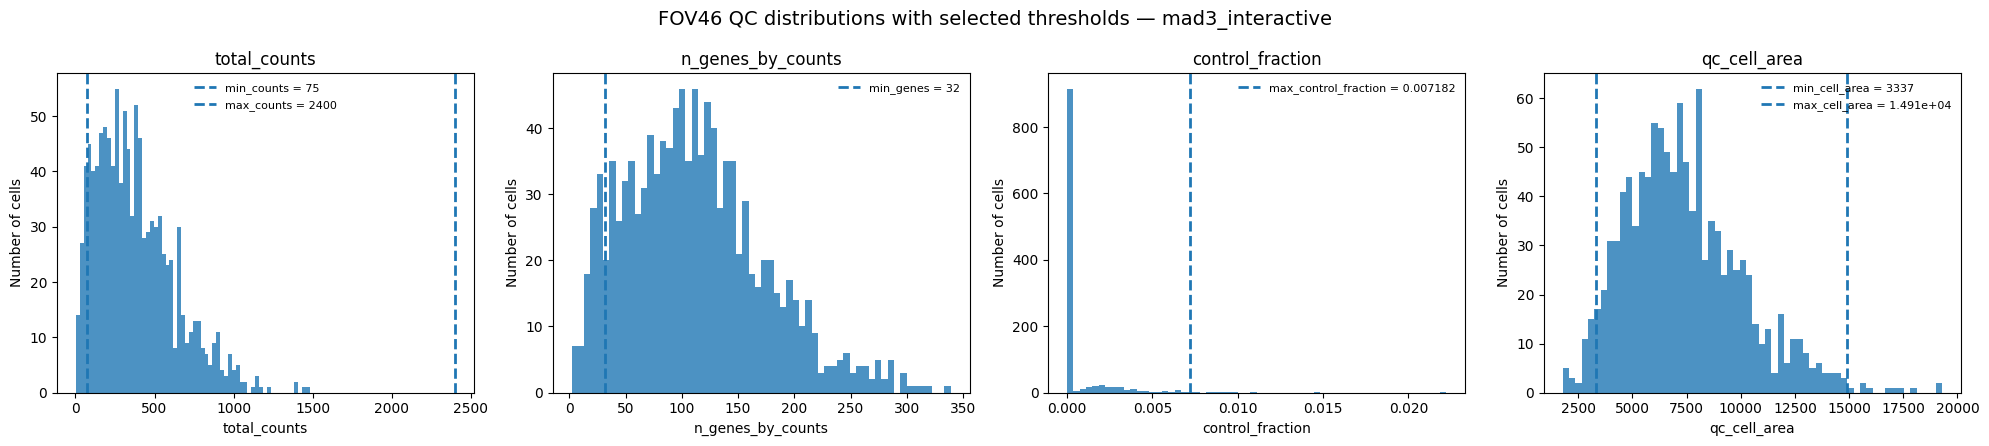

In [33]:
# ============================================================
# QC distributions with the exact selected thresholds
# ============================================================
HIST_BINS = 60
SAVE_QC_FIGURES = False

THRESHOLD_MAP = {
    "total_counts": {"lower":"min_counts", "upper":"max_counts"},
    "n_genes_by_counts": {"lower":"min_genes", "upper":"max_genes"},
    "control_fraction": {"lower":None, "upper":"max_control_fraction"},
    "qc_cell_area": {"lower":"min_cell_area", "upper":"max_cell_area"},
}

QC_OUTPUT_DIR = RESULTS_DIR / "FOV46" / "qc_variants" / QC_TAG
QC_FIGURE_DIR = QC_OUTPUT_DIR / "figures"
THRESHOLD_FIGURE_FILE = QC_FIGURE_DIR / f"qc_metric_distributions_with_thresholds_{QC_TAG}.png"

def _thr(name):
    if name is None: return None
    v = QC_THRESHOLDS.get(name)
    if v is None: return None
    try: v=float(v)
    except (TypeError,ValueError): return None
    return v if np.isfinite(v) else None

fig, axes = plt.subplots(1, len(qc_columns), figsize=(5*len(qc_columns),4.5))
axes=np.atleast_1d(axes)
for ax,col in zip(axes,qc_columns):
    vals=pd.to_numeric(f46.obs[col],errors="coerce").replace([np.inf,-np.inf],np.nan).dropna()
    ax.hist(vals,bins=HIST_BINS,alpha=.8)
    info=THRESHOLD_MAP.get(col,{})
    for side in ["lower","upper"]:
        name=info.get(side); value=_thr(name)
        if value is not None:
            ax.axvline(value,linestyle="--",linewidth=2,label=f"{name} = {value:.4g}")
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel("Number of cells")
    if ax.get_legend_handles_labels()[0]: ax.legend(frameon=False,fontsize=8)
fig.suptitle(f"FOV46 QC distributions with selected thresholds — {QC_TAG}",fontsize=14)
fig.tight_layout()
if SAVE_QC_FIGURES:
    QC_FIGURE_DIR.mkdir(parents=True,exist_ok=True)
    fig.savefig(THRESHOLD_FIGURE_FILE,dpi=300,bbox_inches="tight")
    print("Saved:",THRESHOLD_FIGURE_FILE)
plt.show()


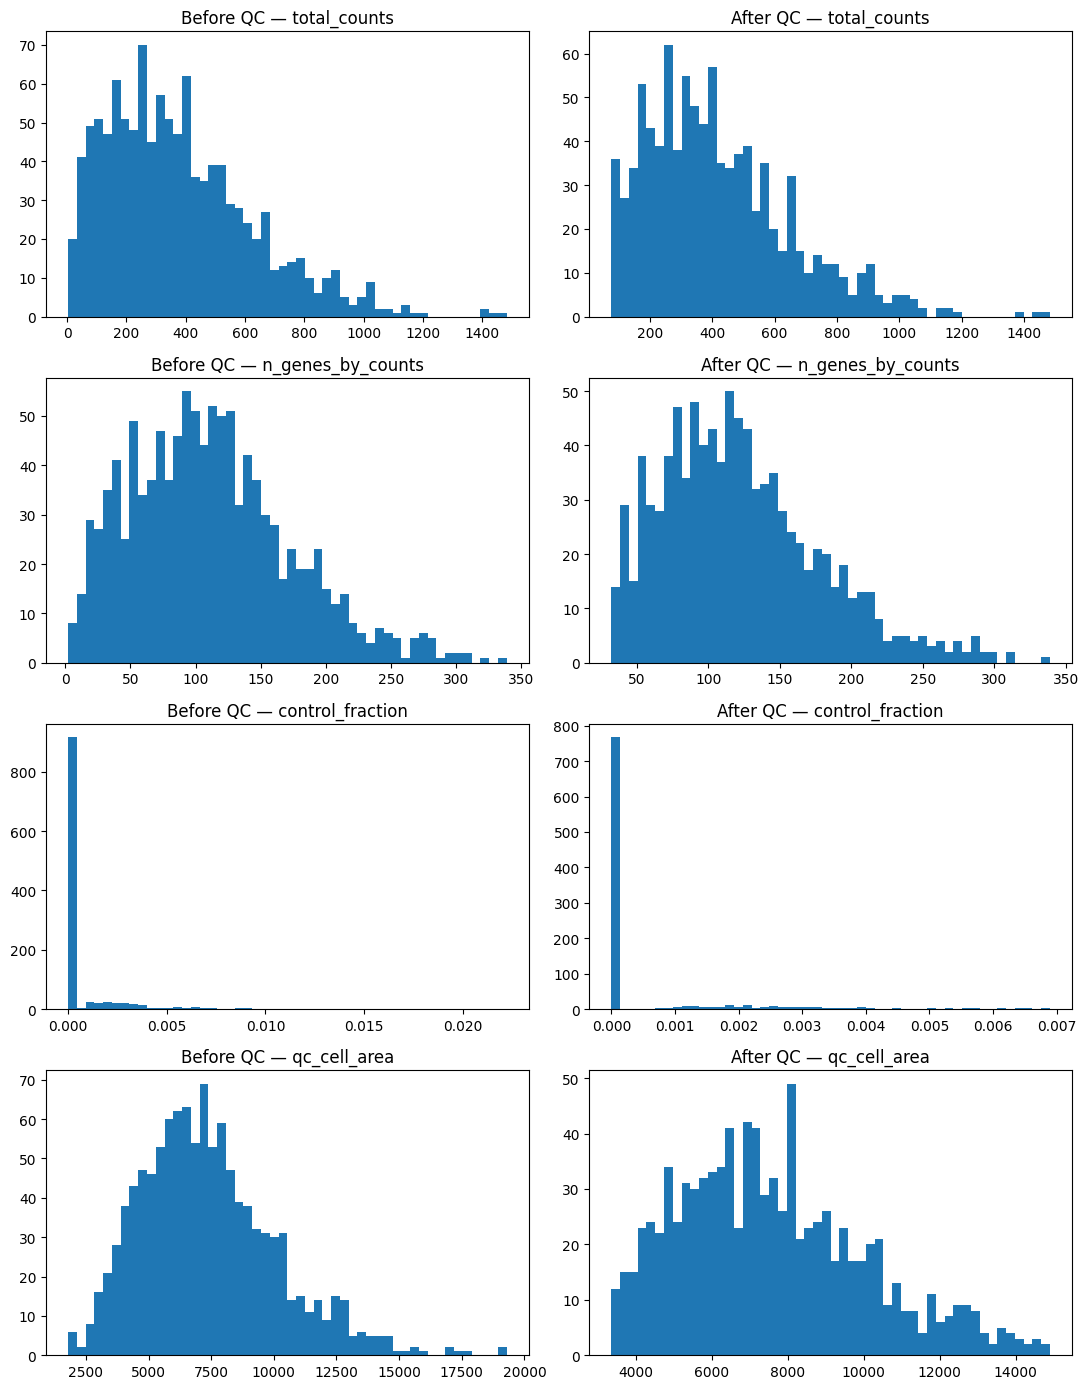

In [34]:
# Before/after distributions.
fig, axes = plt.subplots(len(qc_columns), 2, figsize=(11, 3.5*len(qc_columns)))
axes=np.atleast_2d(axes)
for i,col in enumerate(qc_columns):
    before=pd.to_numeric(f46.obs[col],errors="coerce").dropna()
    after=pd.to_numeric(f46.obs.loc[keep,col],errors="coerce").dropna()
    axes[i,0].hist(before,bins=50); axes[i,0].set_title(f"Before QC — {col}")
    axes[i,1].hist(after,bins=50); axes[i,1].set_title(f"After QC — {col}")
plt.tight_layout(); plt.show()


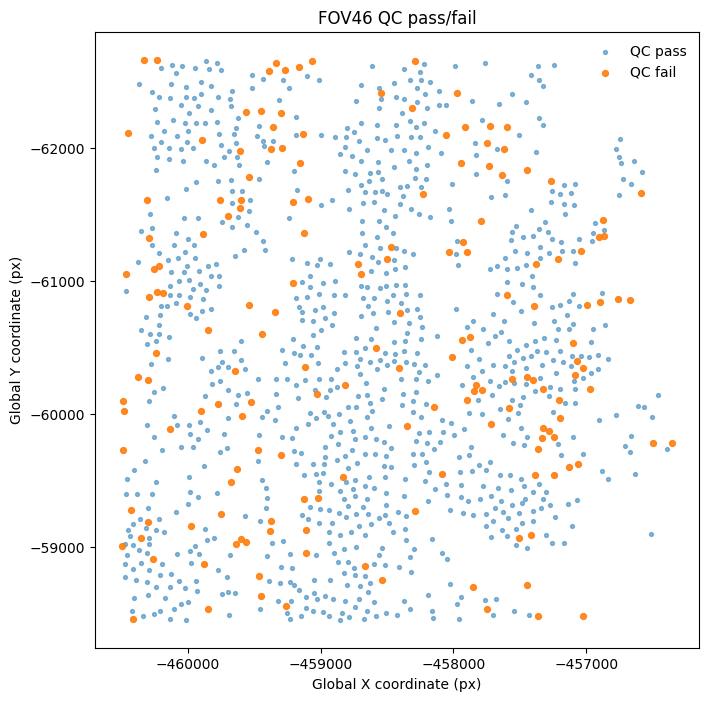

In [35]:
# Spatial QC pass/fail — essential for spatial data.
xy=np.asarray(f46.obsm["spatial"])
fig,ax=plt.subplots(figsize=(8,8))
ax.scatter(xy[keep,0],xy[keep,1],s=8,alpha=.5,label="QC pass")
ax.scatter(xy[~keep,0],xy[~keep,1],s=18,alpha=.9,label="QC fail")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xlabel("Global X coordinate (px)"); ax.set_ylabel("Global Y coordinate (px)")
ax.legend(frameon=False); ax.set_title("FOV46 QC pass/fail"); plt.show()

In [36]:
# ============================================================
# Build filtered biological object in memory
# ============================================================

biological = ~control_mask(f46.var_names)

q = f46[
    keep.to_numpy(),
    biological,
].copy()

sc.pp.filter_genes(
    q,
    min_cells=1,
)

# Preserve raw biological counts
q.layers["counts"] = q.X.copy()

print(q)

AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_fov'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_control', 'n_cells'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'


In [37]:
# ============================================================
# Versioned QC output configuration
# ============================================================
SAVE_QC = False

QC_OUTPUT_DIR = RESULTS_DIR / "FOV46" / "qc_variants" / QC_TAG
QC_OUTPUT_FILE = QC_OUTPUT_DIR / f"GSM9046088_FOV46_qc_filtered_{QC_TAG}.h5ad"
QC_THRESHOLDS_FILE = QC_OUTPUT_DIR / f"qc_thresholds_{QC_TAG}.json"
QC_SWEEP_FILE = QC_OUTPUT_DIR / f"qc_threshold_sweep_{QC_TAG}.csv"

print("="*70)
print("QC output plan")
print("="*70)
print("SAVE_QC          :", SAVE_QC)
print("QC_TAG           :", QC_TAG)
print("Output directory :", QC_OUTPUT_DIR)
print("Output filename  :", QC_OUTPUT_FILE.name)
print("Full output path :", QC_OUTPUT_FILE)
print("Currently exists :", QC_OUTPUT_FILE.exists())


QC output plan
SAVE_QC          : False
QC_TAG           : mad3_interactive
Output directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive
Output filename  : GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad
Full output path : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad
Currently exists : True


In [38]:
# ============================================================
# Save only after interactive inspection is complete
# ============================================================
if SAVE_QC:
    QC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    q.write_h5ad(QC_OUTPUT_FILE, compression="gzip")
    QC_THRESHOLDS_FILE.write_text(json.dumps(QC_THRESHOLDS, indent=2))
    if qc_sweep is not None:
        qc_sweep.to_csv(QC_SWEEP_FILE, index=False)
    print("Saved AnnData   :", QC_OUTPUT_FILE)
    print("Saved thresholds:", QC_THRESHOLDS_FILE)
else:
    print("SAVE_QC=False — q remains in memory only.")


SAVE_QC=False — q remains in memory only.


In [39]:
# ============================================================
# Verify outputs; reload only if the file actually exists
# ============================================================
print("AnnData exists      :", QC_OUTPUT_FILE.exists())
print("Threshold JSON exists:", QC_THRESHOLDS_FILE.exists())

if QC_OUTPUT_FILE.exists():
    print(f"AnnData size: {QC_OUTPUT_FILE.stat().st_size/1024**2:.2f} MB")
    q_test = sc.read_h5ad(QC_OUTPUT_FILE)
    print("Reload successful:", q_test)
    print("counts layer       :", "counts" in q_test.layers)
    print("spatial coordinates:", "spatial" in q_test.obsm)

if QC_THRESHOLDS_FILE.exists():
    with open(QC_THRESHOLDS_FILE) as fh:
        saved_qc = json.load(fh)
    print("Saved thresholds:")
    display(saved_qc)


AnnData exists      : True
Threshold JSON exists: True
AnnData size: 0.73 MB
Reload successful: AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_fov'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_control', 'n_cells'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'
counts layer       : True
spatial coordinates: True
Saved thresholds:


{'min_counts': 75,
 'min_genes': 32,
 'max_counts': 2400,
 'max_control_fraction': 0.007182337045669567,
 'min_cell_area': 3337.0824715846375,
 'max_cell_area': 14913.890936282127}